In [1]:
!pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import log_loss, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
import os
import missingno as msno
import warnings
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/home/andy/dataset_master_grouped.csv')
df

,image_id,class_label,hist_mean,hist_std,hist_skew,hist_kurtosis,perc_05,perc_25,perc_50,perc_75,...,glcm_homogeneity,glcm_energy,glcm_correlation,hu_moment_0,hu_moment_1,hu_moment_2,hu_moment_3,hu_moment_4,hu_moment_5,hu_moment_6
0,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,Perfetta,129.673031,74.038264,-0.009050,-1.203356,13.0,66.0,130.0,194.0,...,0.387288,0.024185,0.997688,2.911848,7.840610,9.642271,9.817405,10.0,-9.999975,10.0
1,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,Negativo,125.326969,74.038264,0.009050,-1.203356,11.0,61.0,125.0,189.0,...,0.387288,0.024185,0.997688,2.964610,7.412966,9.781926,9.970247,-10.0,-9.999997,10.0
2,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,Contrast_Stretching,115.326710,20.486525,-0.008513,-1.204137,83.0,98.0,115.0,133.0,...,0.707691,0.074838,0.997504,2.836139,9.443552,9.913824,9.957017,10.0,-10.000000,10.0
3,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,Gray_Level_Slicing,60.938145,73.128458,1.126350,-0.005590,0.0,2.0,26.0,102.0,...,0.519834,0.185854,0.996074,2.659048,6.157160,8.992812,8.968283,10.0,-9.996701,10.0
4,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,Inutilizzabile,128.832607,59.388733,-0.009994,-1.299884,39.0,75.0,128.0,184.0,...,0.416001,0.025957,0.999146,2.896528,8.195202,9.717220,9.839786,10.0,-9.999986,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,pae_car_0768.jpg,Inutilizzabile,110.268223,71.632766,0.229611,-0.935095,3.0,58.0,102.0,166.0,...,0.760265,0.054475,0.987280,2.892403,7.590771,9.615904,9.835581,-10.0,-9.999973,-10.0
14996,pae_car_0769.jpg,Inutilizzabile,121.368324,86.863560,0.171902,-1.334911,1.0,43.0,115.0,197.0,...,0.777667,0.102852,0.992503,2.834760,7.278398,9.845837,9.641444,10.0,9.999991,-10.0
14997,pae_car_0770.jpg,Inutilizzabile,85.015656,70.525387,0.767454,-0.525325,2.0,30.0,63.0,131.0,...,0.757796,0.063888,0.989027,2.622772,7.508014,9.220726,9.675547,10.0,9.999951,-10.0
14998,pae_car_0771.jpg,Inutilizzabile,109.052643,53.179340,-0.291025,-0.987187,17.0,67.0,118.0,151.0,...,0.766656,0.056496,0.986003,2.833779,7.644129,9.643493,9.950316,10.0,-9.999996,10.0


<Axes: >

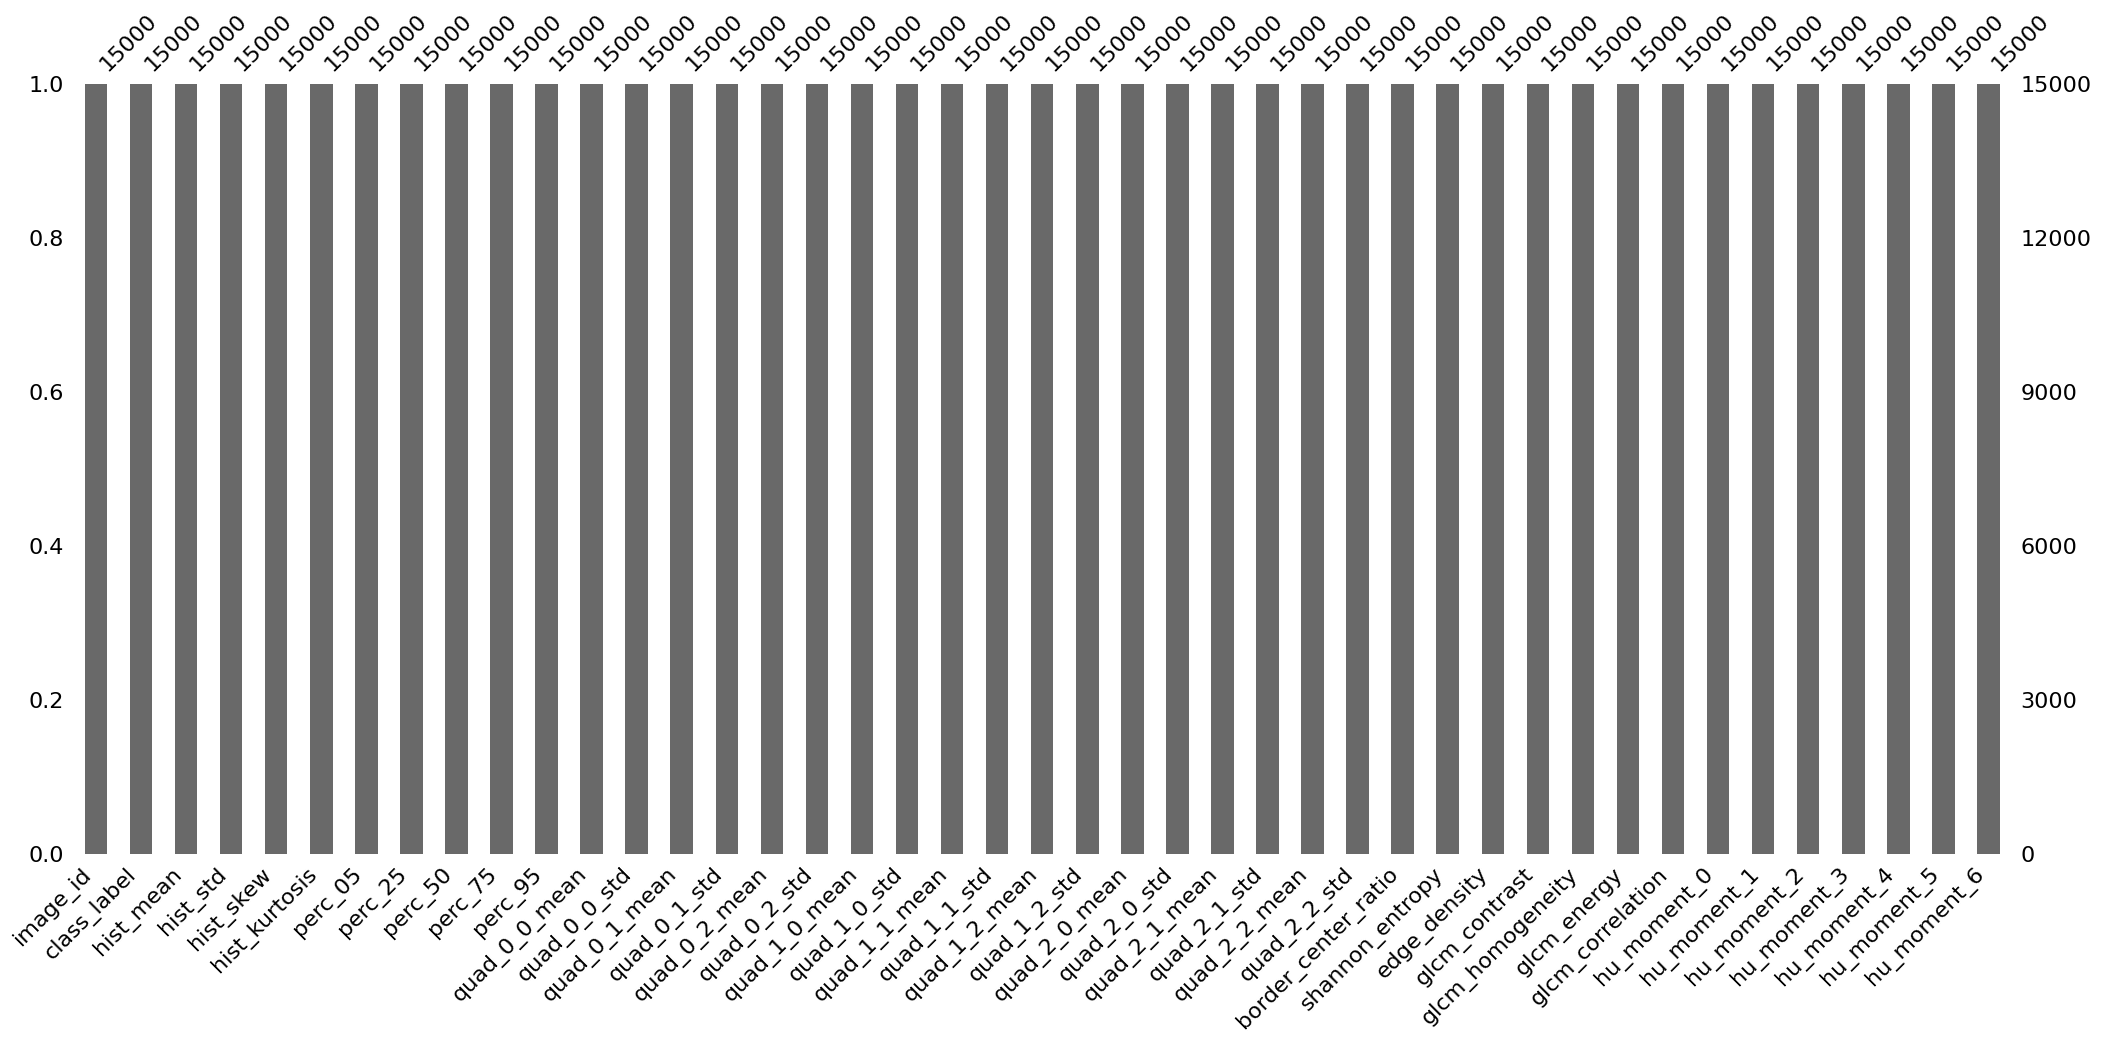

In [4]:
msno.bar(df)

In [5]:
df_corr = df.copy()
le = LabelEncoder()
df_corr['class_label'] = le.fit_transform(df_corr['class_label'])
colonne_da_escludere = ['image_id', 'class_label']
X_features = df.drop(columns=colonne_da_escludere)

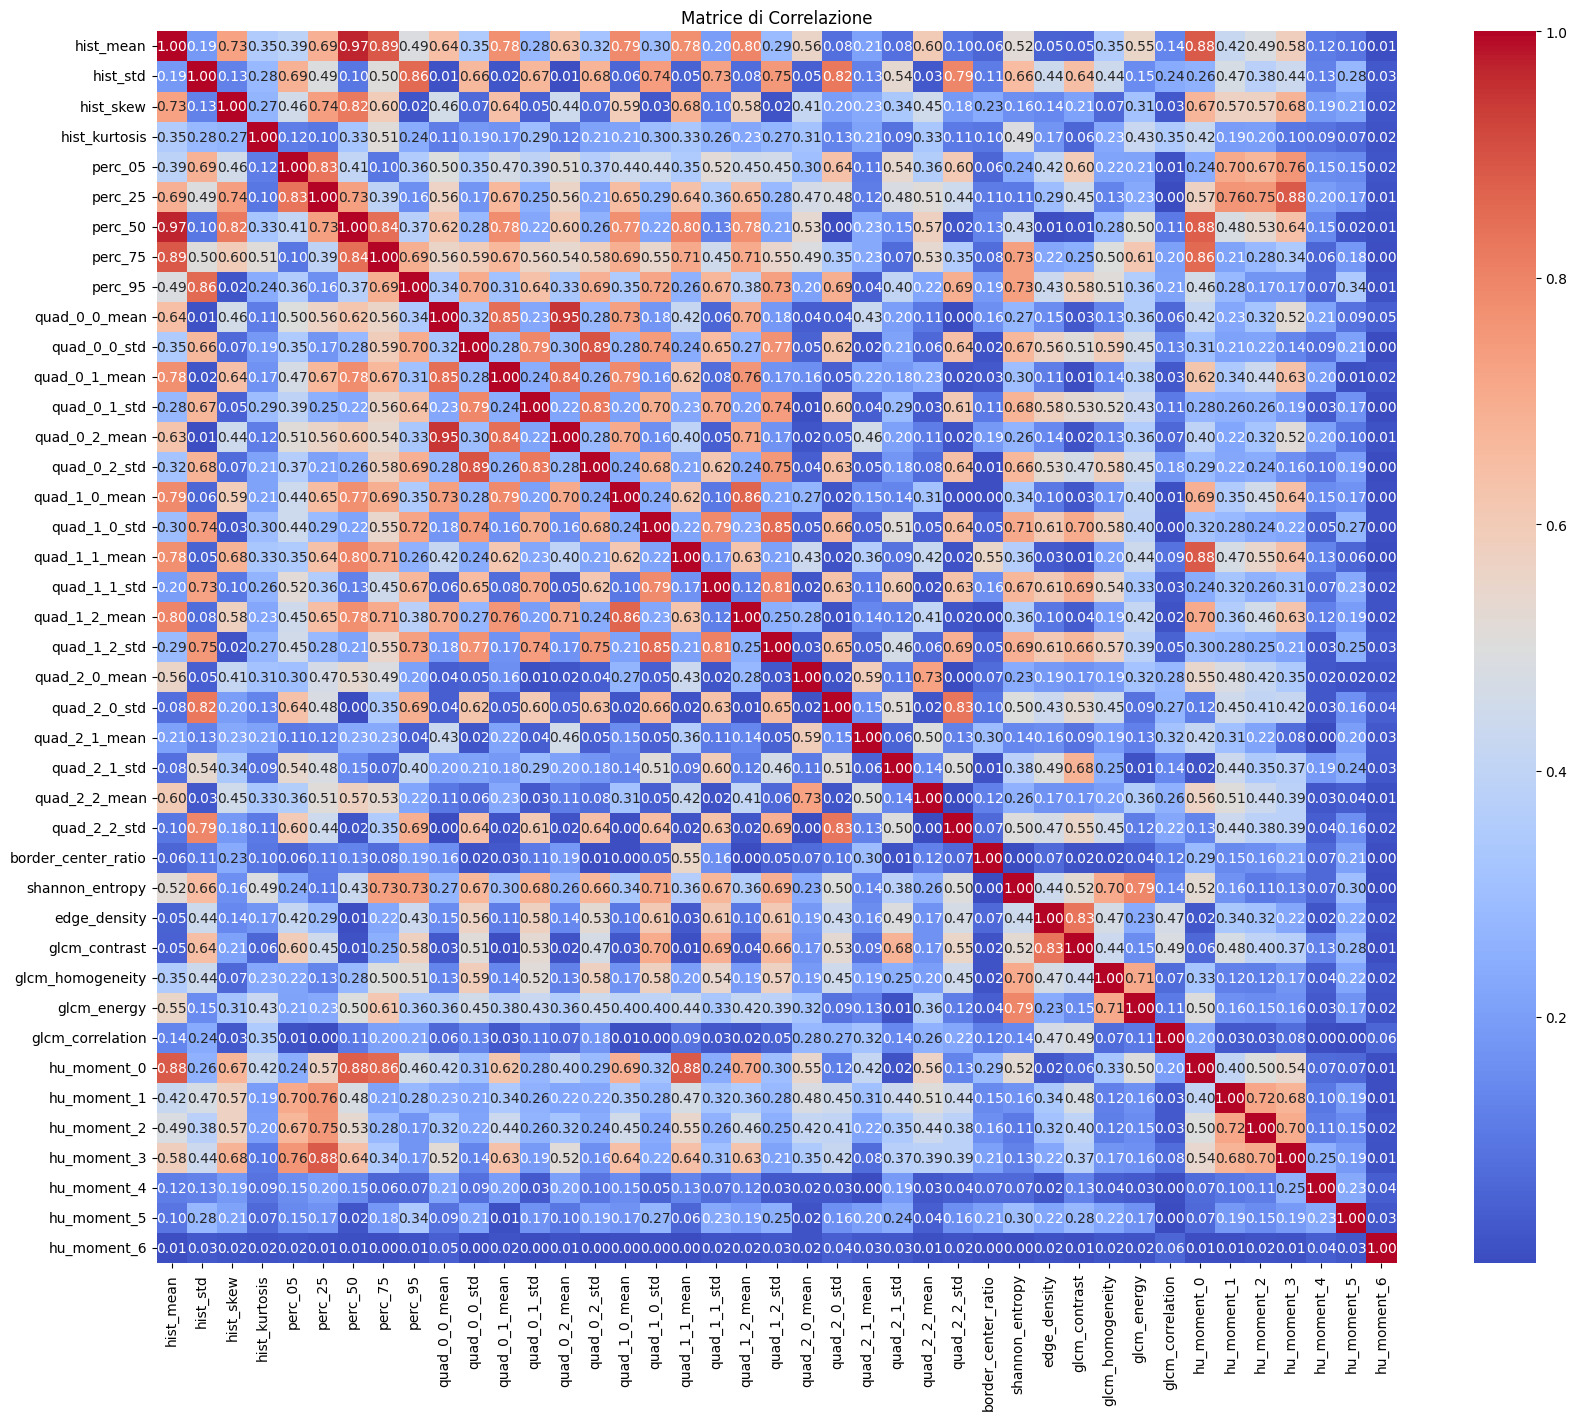

In [6]:
plt.figure(figsize=(20, 16))
sns.heatmap(X_features.corr(method='spearman').abs(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice di Correlazione")
plt.show()

In [7]:
def calcola_vif_attuale(X):
    """Funzione di supporto per ricalcolare il VIF a ogni giro"""
    X_const = add_constant(X)
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_const.columns
    vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]
    return vif_df[vif_df['Feature'] != 'const'].sort_values(by="VIF", ascending=False).reset_index(drop=True)

In [8]:
display(calcola_vif_attuale(X_features))

,Feature,VIF
0,hist_mean,19079.040719
1,quad_2_1_mean,979.734463
2,quad_0_2_mean,617.600530
3,quad_0_0_mean,591.506113
4,quad_0_1_mean,504.167924
5,quad_1_0_mean,414.593795
6,quad_2_2_mean,407.405176
7,quad_2_0_mean,402.308994
8,quad_1_2_mean,397.126425
9,quad_1_1_mean,349.141800


In [9]:
colonne_quad = [col for col in X_features.columns if col.startswith('quad_')]
colonne_percentili = ['perc_05', 'perc_25', 'perc_50', 'perc_75', 'perc_95']
colonne_da_scartare_manuale = colonne_quad + colonne_percentili

if 'hist_mean' in X_features.columns:
    colonne_da_scartare_manuale.append('hist_mean')

if 'hist_std' in X_features.columns:
    colonne_da_scartare_manuale.append('hist_std')

colonne_da_scartare_manuale = [col for col in colonne_da_scartare_manuale if col in X_features.columns]

X_features = X_features.drop(columns=colonne_da_scartare_manuale).copy()

In [10]:
SOGLIA_VIF = 5.0

while True:
    vif_corrente = calcola_vif_attuale(X_features)
       
    if vif_corrente.empty or vif_corrente.iloc[0]["VIF"] < SOGLIA_VIF:
        break
        
    feature_peggiore = vif_corrente.iloc[0]["Feature"]
    X_features = X_features.drop(columns=[feature_peggiore])

features_sopravvissute = X_features.columns.tolist()

In [11]:
display(calcola_vif_attuale(X_features))

,Feature,VIF
0,hu_moment_2,3.173154
1,edge_density,2.673003
2,glcm_contrast,2.656227
3,hu_moment_1,2.262950
4,glcm_energy,2.131446
5,hist_kurtosis,1.772895
6,glcm_homogeneity,1.686530
7,border_center_ratio,1.339496
8,hu_moment_5,1.211349
9,hu_moment_4,1.081878


In [12]:
df_finale = df_corr[['image_id', 'class_label'] + features_sopravvissute].copy()
df_finale

,image_id,class_label,hist_kurtosis,border_center_ratio,edge_density,glcm_contrast,glcm_homogeneity,glcm_energy,hu_moment_1,hu_moment_2,hu_moment_4,hu_moment_5,hu_moment_6
0,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,4,-1.203356,1.293655,0.028706,25.351268,0.387288,0.024185,7.840610,9.642271,10.0,-9.999975,10.0
1,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,3,-1.203356,0.802829,0.028706,25.351268,0.387288,0.024185,7.412966,9.781926,-10.0,-9.999997,10.0
2,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,0,-1.204137,1.077164,0.000725,2.095501,0.707691,0.074838,9.443552,9.913824,10.0,-10.000000,10.0
3,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,1,-0.005590,2.568009,0.027401,42.013572,0.519834,0.185854,6.157160,8.992812,10.0,-9.996701,10.0
4,mimic_5d8856f9-8c007498-c027e57a-2d839676-ca8b...,2,-1.299884,1.231351,0.000732,6.027321,0.416001,0.025957,8.195202,9.717220,10.0,-9.999986,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,pae_car_0768.jpg,2,-0.935095,0.791637,0.087994,130.738484,0.760265,0.054475,7.590771,9.615904,-10.0,-9.999973,-10.0
14996,pae_car_0769.jpg,2,-1.334911,1.324673,0.097645,112.972255,0.777667,0.102852,7.278398,9.845837,10.0,9.999991,-10.0
14997,pae_car_0770.jpg,2,-0.525325,1.707529,0.092106,108.773392,0.757796,0.063888,7.508014,9.220726,10.0,9.999951,-10.0
14998,pae_car_0771.jpg,2,-0.987187,1.019328,0.080952,79.126773,0.766656,0.056496,7.644129,9.643493,10.0,-9.999996,10.0


In [13]:
X = df_finale.drop(columns=['class_label'])
y = df_finale['class_label']
gruppi_pazienti = df_finale['image_id']

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=gruppi_pazienti))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
gruppi_temp = gruppi_pazienti.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(X.iloc[temp_idx], y.iloc[temp_idx], groups=gruppi_temp))

X_val, y_val = X.iloc[temp_idx].iloc[val_idx], y.iloc[temp_idx].iloc[val_idx]
X_test, y_test = X.iloc[temp_idx].iloc[test_idx], y.iloc[temp_idx].iloc[test_idx]

X_train = X_train.drop(columns=['image_id'])
X_val = X_val.drop(columns=['image_id'])
X_test = X_test.drop(columns=['image_id'])

print(f"Train set: {X_train.shape[0]} campioni")
print(f"Validation set: {X_val.shape[0]} campioni")
print(f"Test set: {X_test.shape[0]} campioni")

Train set: 11974 campioni
Validation set: 1570 campioni
Test set: 1456 campioni


In [ ]:
MAX_TREES = 10

rf_model = RandomForestClassifier(n_estimators=1, max_depth=2, warm_start=True, random_state=42, n_jobs=-1)

train_loss, val_loss = [], []
best_val_loss = float('inf')
patience_counter = 0
best_n_trees = 1

for i in range(1, MAX_TREES + 1):
    rf_model.n_estimators = i
    rf_model.fit(X_train, y_train)
    
    t_loss = log_loss(y_train, rf_model.predict_proba(X_train))
    v_loss = log_loss(y_val, rf_model.predict_proba(X_val))
    
    train_loss.append(t_loss)
    val_loss.append(v_loss)

rf_model = RandomForestClassifier(n_estimators=best_n_trees, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

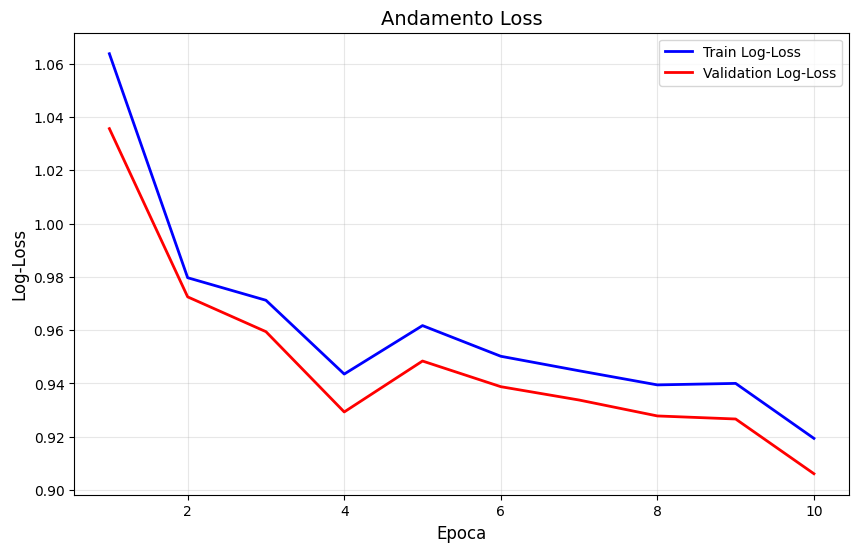

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Log-Loss', color='blue', linewidth=2)
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Log-Loss', color='red', linewidth=2)
plt.title('Andamento Loss', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Log-Loss', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

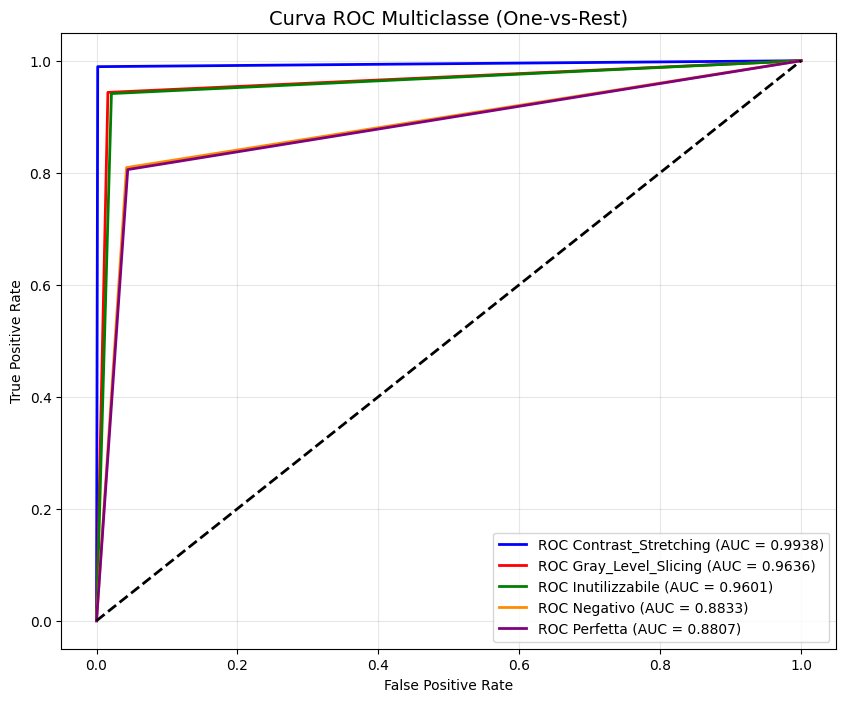


AUC-ROC Score Globale: 0.9370

Classification Report:
                     precision    recall  f1-score   support

Contrast_Stretching       0.99      0.99      0.99       283
 Gray_Level_Slicing       0.93      0.94      0.94       283
     Inutilizzabile       0.93      0.94      0.93       324
           Negativo       0.82      0.81      0.81       283
           Perfetta       0.81      0.81      0.81       283

           accuracy                           0.90      1456
          macro avg       0.90      0.90      0.90      1456
       weighted avg       0.90      0.90      0.90      1456



In [34]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)
classi_nomi = list(le.classes_)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'darkorange', 'purple']
for i, color in zip(range(5), colors):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, color=color, lw=2, label=f'ROC {classi_nomi[i]} (AUC = {auc_i:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Curva ROC Multiclasse (One-vs-Rest)', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Report finale
auc_roc_globale = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f"\nAUC-ROC Score Globale: {auc_roc_globale:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classi_nomi))

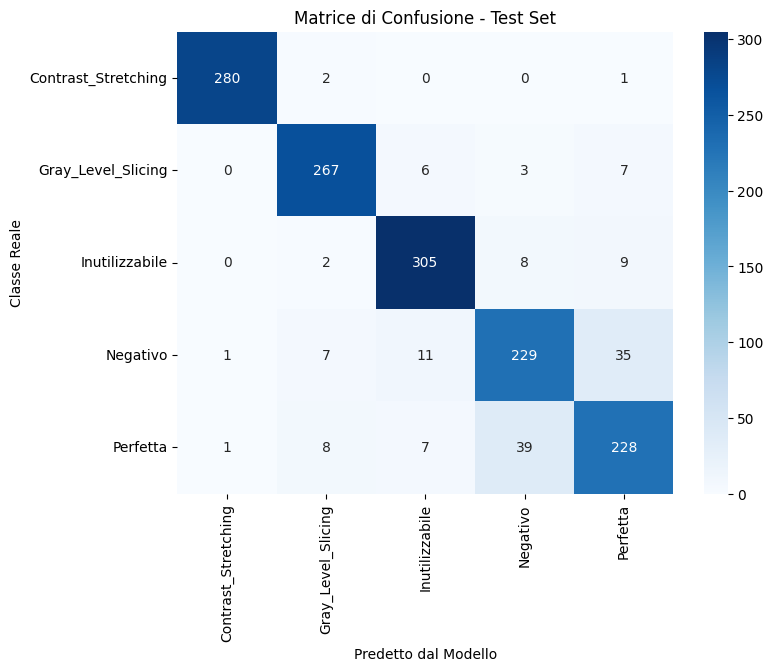

In [35]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classi_nomi, yticklabels=classi_nomi)
plt.xlabel('Predetto dal Modello')
plt.ylabel('Classe Reale')
plt.title('Matrice di Confusione - Test Set')
plt.show()

In [36]:
percorso_salvataggio = '/home/andy/Documenti/Tesi-Magistrale/models_saved/controllo_qualita/controllo_qualita.joblib'

features_finali = X_train.columns.tolist()

pacchetto_modello = {
    'modello_rf': rf_model,
    'label_encoder': le,
    'feature_names': features_finali
}

joblib.dump(pacchetto_modello, percorso_salvataggio)

dimensione_mb = os.path.getsize(percorso_salvataggio) / (1024 * 1024)
print(f"SALVATAGGIO COMPLETATO!")
print(f"File salvato in: {percorso_salvataggio}")
print(f"Dimensione file: {dimensione_mb:.2f} MB")
print(f"Feature memorizzate: {features_finali}")

SALVATAGGIO COMPLETATO!
File salvato in: /home/andy/Documenti/Tesi-Magistrale/models_saved/controllo_qualita/controllo_qualita.joblib
Dimensione file: 0.13 MB
Feature memorizzate: ['hist_kurtosis', 'border_center_ratio', 'edge_density', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'hu_moment_1', 'hu_moment_2', 'hu_moment_4', 'hu_moment_5', 'hu_moment_6']
